## Data analysis


### 1. Import necessary library


In [1]:
import os
import pandas as pd
import dev_configuration
import dev_dataprocesses
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image, ImageChops
from skimage import io


2024-12-14 22:33:03.244777: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-14 22:33:03.244880: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-14 22:33:03.244911: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-14 22:33:03.328747: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### 2. Helper functions

In [2]:
'''
'''
def load_dataset(
        preconfigured_dataset = 'sport-balls',
        datapaths =dict(),
        labels = None,
        dataset_original_path = "",
        isverbose = False,
):
    """

    :param preconfigured_dataset:
    :param datapaths:
    :param labels:
    :param dataset_original_path:
    :param isverbose:
    :return:
    """
    isverbose = dev_configuration.isverbose
    if preconfigured_dataset in dev_configuration.datasets:
        #TODO: Correct the path with PWD-like functions
        dataset_original_path = f"./datasets/{preconfigured_dataset}"
    else:
        return print(f"Invalid preconfigured dataset: {preconfigured_dataset}")

    print(f"Processing {dataset_original_path}")
    datasource_dict = {
        "train": None,
        "test": None,
        "val": None
    }

    data_splits = os.listdir(dataset_original_path)
    for split in data_splits:
        files_fullpaths2 = []
        labels_list2 = []
        print(f"Processing {split} set")
        split_path = os.path.join(dataset_original_path, split)
        if os.path.isdir(f"{split_path}"):
            for label in os.listdir(f"{split_path}"):
                label_path = os.path.join(split_path, label)
                files_list = os.listdir(label_path)
                files_fullpaths2.extend([os.path.join(label_path, fpath) for fpath in files_list])
                labels_list2.extend([label] * len(files_list))

        # put in pandas dataframe
        pd_data = pd.DataFrame(list(zip(files_fullpaths2, labels_list2)), columns=['filepath', 'label'])
        if split in datasource_dict.keys():
            datasource_dict[split] = pd_data
        else:
            print(f"split {split} not in datasource_dict")

    if isverbose:
        print(f" processes completed"
              f"\n {len(datasource_dict)}")
        for split in datasource_dict:
            pd_data_item = datasource_dict[split]
            if pd_data_item is not None:
                print(f"\n Label: {split} "
                      f"\nLength is : {len(pd_data_item)}"
                      f"\nSample head: \n {pd_data_item.head()}"
                      f"\nSample shape: \n {pd_data_item.shape}"
                      f"\nValue counts: \n {pd_data_item['label'].value_counts()}"
                      f"==================")
            else:
                print(f"\n Label: {split} is None")

    return datasource_dict



In [3]:
"""
Data generators helpers
1. Keras data generator
2. Sklearn generator

"""

def data_generators(datasource: None, data_generator:'keras'):
    """

    :param datasource:
    :param data_generator:
    :return:
    """
    if datasource is None:
        return print('Datasource is None')

    is_train_test_only = False
    # default configuration
    test_split_value = dev_configuration.test_split_value
    val_split_value = dev_configuration.val_split_value
    randomState_value = dev_configuration.randomState_value
    default_xcol_value = dev_configuration.default_xcol_value
    default_ycol_value = dev_configuration.default_ycol_value
    batch_size = dev_configuration.batch_size
    isShuffle = dev_configuration.isShuffle
    train_set = None

    print(f" processing from datasources:"
          f"\n datasource: {len(datasource)}")
    print(len(datasource))
    for key_item in datasource.keys():
        if datasource[key_item] is not None:
            print(f"data split {key_item}")
            print(datasource[key_item].head())
            print(datasource[key_item].shape)
            print(datasource[key_item]["label"].value_counts())
        else:
            print(f"data split {key_item} is None")
            is_train_test_only = True

    if is_train_test_only:
        train_val_images = datasource["train"]
        test_images = datasource["test"]
        train_set, val_set = train_test_split(
            datasource["train"],
            test_size=val_split_value,
            random_state=randomState_value
        )

        print(train_set.shape)
        print(test_images.shape)
        print(val_set.shape)
        print(train_val_images.shape)

    if data_generator == 'keras':
        '''
        1. No normalization, data augmentation applied. The image will be resized to target value (224 or 244 depending on setting)
        2. Applied several light/weak data augmentation like rotation, shear, flip,...
        '''
        # Approach 1:
        image_gen = ImageDataGenerator()
        # Approach 2:
        # image_gen = ImageDataGenerator(rotation_range=0.45,
        #                     width_shift_range=0.1,
        #                     height_shift_range=0.1,
        #                     zoom_range=0.1,
        #                     horizontal_flip=True,
        #                     vertical_flip=True
        #     )
        # val_gen = ImageDataGenerator(rotation_range=0.45,
        #                              width_shift_range=0.1,
        #                              height_shift_range=0.1,
        #                              zoom_range=0.1,
        #                              horizontal_flip=True,
        #                              vertical_flip=True)
        # ts_gen = ImageDataGenerator(rotation_range=0.45,
        #                             width_shift_range=0.1,
        #                             height_shift_range=0.1,
        #                             zoom_range=0.1,
        #                             horizontal_flip=True,
        #                             vertical_flip=True)
        train_data = image_gen.flow_from_dataframe(dataframe=train_set,
                                                   x_col=default_xcol_value,
                                                   y_col=default_ycol_value,
                                                   target_size=(244, 244),
                                                   color_mode='rgb',
                                                   class_mode="categorical",
                                                   batch_size=batch_size,
                                                   shuffle=isShuffle
                                                   )
        test_data = image_gen.flow_from_dataframe(dataframe=test_images,
                                                  x_col=default_xcol_value,
                                                  y_col=default_ycol_value,
                                                  target_size=(244, 244),
                                                  color_mode='rgb',
                                                  class_mode="categorical",
                                                  batch_size=batch_size,
                                                  shuffle=isShuffle
                                                  )
        val_data = image_gen.flow_from_dataframe(dataframe=val_set,
                                                 x_col=default_xcol_value,
                                                 y_col=default_ycol_value,
                                                 target_size=(244, 244),
                                                 color_mode='rgb',
                                                 class_mode="categorical",
                                                 batch_size=batch_size,
                                                 shuffle=isShuffle
                                                 )
    else:
        # Sklearn method has not been implemented yet.
        train_data = []
        val_data = []
        test_data = []

        return train_data, val_data, test_data

In [4]:
# Debug flags
isDebug = True
isVerbose = True
randomState_value = 2024
# hard code for now.
dataset_name = 'sport-balls'

loaded_datasets = dev_dataprocesses.load_dataset(preconfigured_dataset=dataset_name)

train_data, val_data, test_data = dev_dataprocesses.data_generators(datasource=loaded_datasets,
                                                                    data_generator='keras')

Processing /home/phuocddat/Workspace/git/med/Introduction-to-AI-Group-14-/Project/datasets/sport-balls
Processing train set
Processing test set
 processes completed
 3

 Label: train 
Length is : 7328
Sample head: 
                                             filepath         label
0  /home/phuocddat/Workspace/git/med/Introduction...  bowling_ball
1  /home/phuocddat/Workspace/git/med/Introduction...  bowling_ball
2  /home/phuocddat/Workspace/git/med/Introduction...  bowling_ball
3  /home/phuocddat/Workspace/git/med/Introduction...  bowling_ball
4  /home/phuocddat/Workspace/git/med/Introduction...  bowling_ball
Sample shape: 
 (7328, 2)
Value counts: 
 label
billiard_ball        646
table_tennis_ball    620
football             604
cricket_ball         581
golf_ball            549
hockey_ball          530
rugby_ball           493
tennis_ball          490
bowling_ball         440
volleyball           432
shuttlecock          429
baseball             400
hockey_puck          390
american_

In [5]:
# Dataset distribution

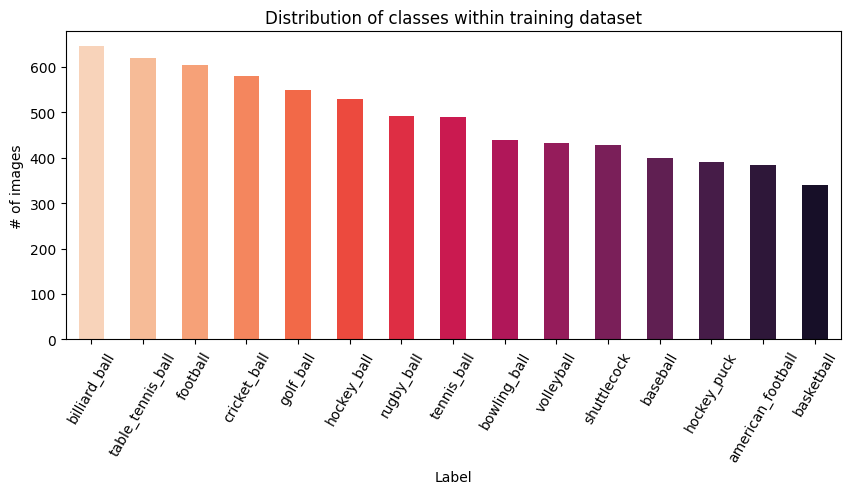

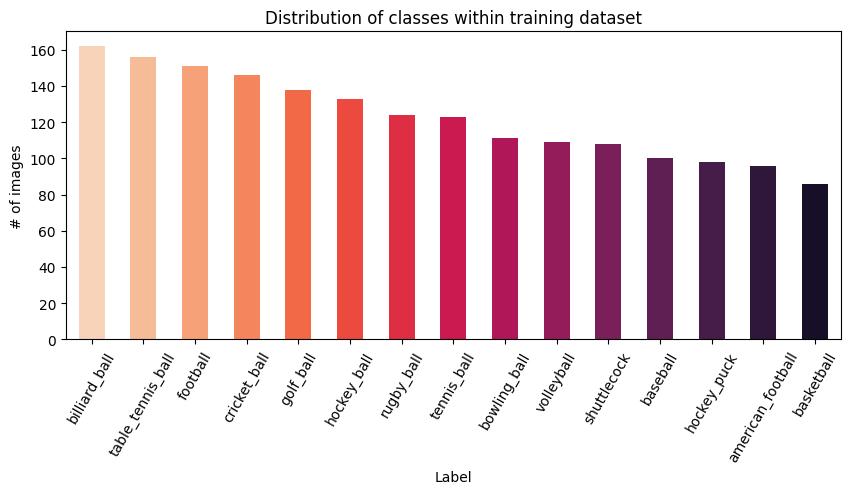

In [6]:

# check distribution of train dataset
plt.figure(figsize=(10,4))
check_dataset = loaded_datasets["train"]
check_dataset_labels = check_dataset["label"].value_counts()
# print(check_dataset_labels)
pal = sns.color_palette("rocket_r", len(check_dataset_labels))
rank = check_dataset_labels.argsort().argsort()
labels_dict = check_dataset_labels.keys()
ax = check_dataset_labels.plot(kind='bar', stacked=True, color=pal)
plt.title("Distribution of classes within training dataset")
plt.ylabel("# of images")
plt.xlabel("Label")
ax.set_xticklabels(ax.get_xticklabels(), rotation=60);

# check distribution of val dataset
plt.figure(figsize=(10,4))
check_dataset = loaded_datasets["test"]
check_dataset_labels = check_dataset["label"].value_counts()
#print(check_dataset_labels)
pal = sns.color_palette("rocket_r", len(check_dataset_labels))
rank = check_dataset_labels.argsort().argsort()
labels_dict = check_dataset_labels.keys()
ax = check_dataset_labels.plot(kind='bar', stacked=True, color=pal)
plt.title("Distribution of classes within training dataset")
plt.ylabel("# of images")
plt.xlabel("Label")
ax.set_xticklabels(ax.get_xticklabels(), rotation=60);


In [7]:
images_list = []
for loc_id, row_value in check_dataset.iterrows():
    # print(f"**loc_id: {loc_id} \n row: -{row_value}")
    read_image = cv2.imread(row_value["filepath"])
    images_list.append(read_image.shape)

check_dataset["imagesize"] = images_list
#print(check_dataset.head())

plt.figure(figsize=(12,7))
import numpy as np



<Figure size 1200x700 with 0 Axes>

/tmp/ipykernel_6218/4008718055.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(height, hist=True, ax=axes[0], color="g")
/tmp/ipykernel_6218/4008718055.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(width, hist=True, ax=axes[1], color="r")
/tmp/ipykernel_6218/4008718055.py:10: UserWarni

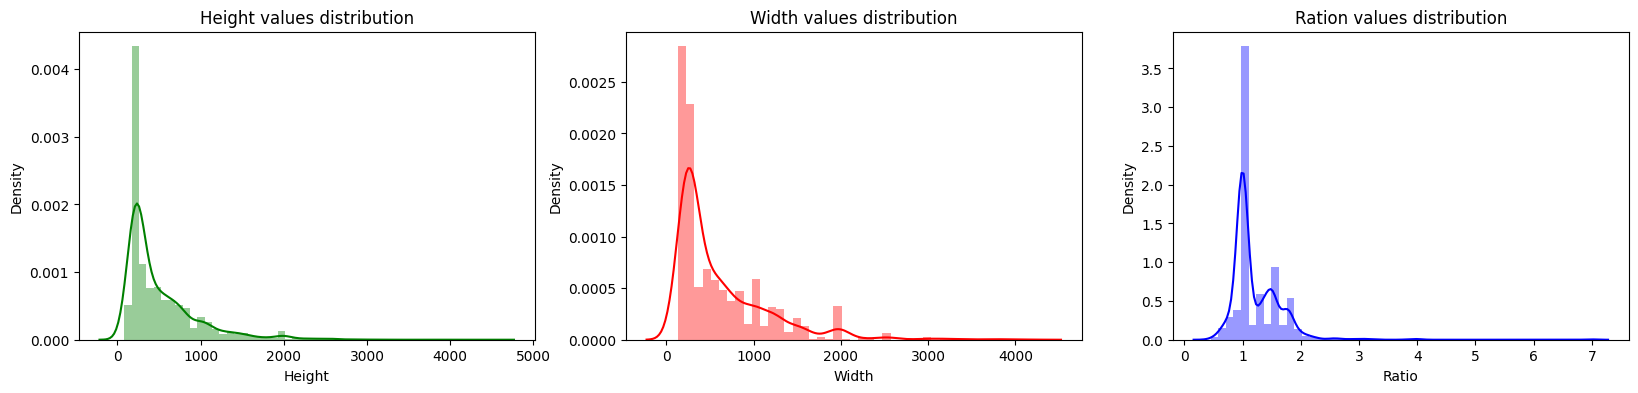

In [8]:
height = check_dataset["imagesize"].apply(lambda x: x[0])
width = check_dataset["imagesize"].apply(lambda x: x[1])
ratio = width/height

# Plotting distributions
f, axes = plt.subplots(figsize=(20,4), ncols=3, nrows=1)

sns.distplot(height, hist=True, ax=axes[0], color="g")
sns.distplot(width, hist=True, ax=axes[1], color="r")
sns.distplot(ratio, hist=True, ax=axes[2], color="b")

axes[0].set_xlabel("Height")
axes[1].set_xlabel("Width")
axes[2].set_xlabel("Ratio")

axes[0].title.set_text('Height values distribution')
axes[1].title.set_text('Width values distribution')
axes[2].title.set_text('Ration values distribution')

mean_ratio = np.mean(ratio)
scale_height = np.mean(height)
scale_width = scale_height * mean_ratio

scaling_size = (int(scale_width), int(scale_height))

# print(f"Rescaling to h: {scale_height}, w: {scale_width}");

## Data exploration



### Problematic examples